# Support Vector Machines: Effect of Kernels on Decision Boundaries

## 1. Introduction

Support Vector Machines are widely used due to their strong theoretical foundation and generalisation ability (Cortes and Vapnik, 1995). They are particularly effective in high-dimensional spaces and can model both linear and non-linear relationships.

This notebook investigates how different kernel functions affect decision boundaries and classification performance.

The following kernels are analysed:
- Linear kernel
- Polynomial kernel
- Radial Basis Function (RBF) kernel

The objective is to understand how kernel choice influences model flexibility and accuracy on a non-linear dataset.

## 2. Background

Support Vector Machines were introduced by Cortes and Vapnik (1995) as a method for constructing optimal separating hyperplanes between classes.

The algorithm works by maximising the margin between classes, using support vectors — the data points closest to the decision boundary.

Kernel functions extend SVMs to handle non-linear data by mapping features into higher-dimensional spaces (Shawe-Taylor and Cristianini, 2004).

Common kernels include:
- Linear kernel: produces a straight decision boundary
- Polynomial kernel: introduces curvature
- RBF kernel: creates highly flexible boundaries

The RBF kernel is particularly effective for modelling complex patterns in data (Bishop, 2006).

### Import libraries

The notebook uses `NumPy` for numerical operations, `Matplotlib` for visualisation, and `scikit-learn` for dataset generation and SVM modelling.

In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns

### Define visual style

A colour-blind-friendly palette is used throughout the notebook. Different colour combinations are applied across figures to create visual distinction while preserving readability.

In [64]:
# Colour-blind-friendly palette
BLUE = "#0072B2"
ORANGE = "#E69F00"
GREEN = "#009E73"
PURPLE = "#CC79A7"
SKYBLUE = "#56B4E9"
VERMILLION = "#D55E00"
YELLOW = "#F0E442"
BLACK = "#000000"
DARK_GREY = "#222222"

# Plot settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 3. Dataset and Experimental Setup

### Generate the dataset¶
The make_moons dataset is used because it creates two interleaving classes with a clearly non-linear structure. This makes it suitable for demonstrating the effect of kernel selection in SVM classification.

In [65]:
# Generate synthetic non-linear dataset
X, y = make_moons(n_samples=300, noise=0.22, random_state=42)

# Consistent axis limits for boundary plots
x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

print("Dataset shape:", X.shape)
print("Class labels:", np.unique(y))

Dataset shape: (300, 2)
Class labels: [0 1]


### Define helper functions¶
The helper functions below are used to keep the notebook clean and consistent. They handle:

saving figures
plotting contour lines
plotting filled decision regions
highlighting support vectors

In [66]:
def save_figure(fig, filepath):
    fig.tight_layout()
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")


def make_meshgrid(x_min, x_max, y_min, y_max, resolution=400):
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def plot_points(ax, X, y, class0_color, class1_color, s=60):
    ax.scatter(
        X[y == 0, 0], X[y == 0, 1],
        c=class0_color, edgecolor=DARK_GREY, linewidth=0.6,
        s=s, label="Class 0"
    )
    ax.scatter(
        X[y == 1, 0], X[y == 1, 1],
        c=class1_color, edgecolor=DARK_GREY, linewidth=0.6,
        s=s, label="Class 1"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.2)

## 4. Train SVM Models

Three SVM models are trained using different kernels to compare their behaviour and performance.

1. linear
2. polynomial
3. RBF

These models will be compared visually and quantitatively.

In [67]:
linear_svm = SVC(kernel="linear", C=1.0)
poly_svm = SVC(kernel="poly", degree=3, C=1.0, gamma="scale")
rbf_svm = SVC(kernel="rbf", C=1.0, gamma=1.0)

linear_svm.fit(X, y)
poly_svm.fit(X, y)
rbf_svm.fit(X, y)

linear_acc = accuracy_score(y, linear_svm.predict(X))
poly_acc = accuracy_score(y, poly_svm.predict(X))
rbf_acc = accuracy_score(y, rbf_svm.predict(X))

print(f"Linear kernel accuracy: {linear_acc:.3f}")
print(f"Polynomial kernel accuracy: {poly_acc:.3f}")
print(f"RBF kernel accuracy: {rbf_acc:.3f}")

Linear kernel accuracy: 0.867
Polynomial kernel accuracy: 0.900
RBF kernel accuracy: 0.943


## 5. Results and Visualisation

### Figure 1: Dataset Distribution

This scatter plot shows the dataset structure. The curved shape indicates that the data is not linearly separable.

Saved: figures/figure1_dataset_distribution.png


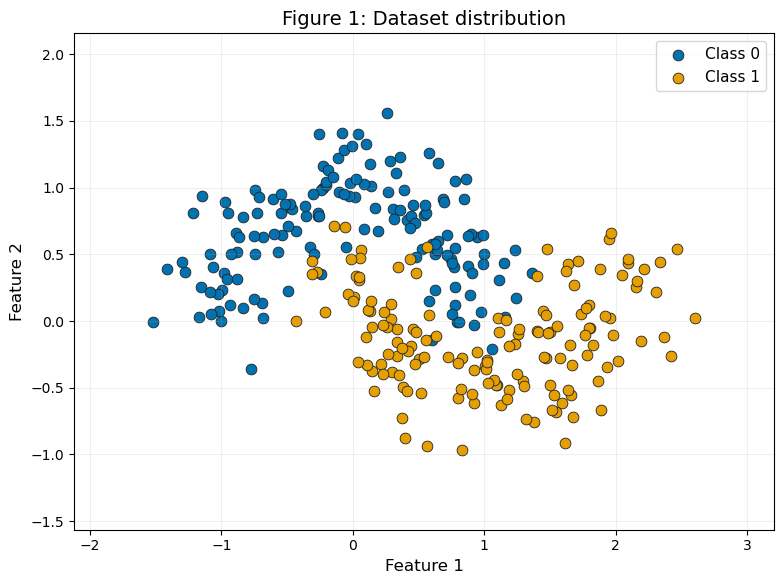

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_points(ax, X, y, BLUE, ORANGE)
ax.set_title("Figure 1: Dataset distribution")
ax.legend(loc="best")
save_figure(fig, "figures/figure1_dataset_distribution.png")
plt.show()

### Figure 2: Linear Kernel Decision Boundary

The linear kernel produces a straight boundary. It cannot capture the curved structure of the dataset, resulting in lower performance.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy, grid = make_meshgrid(x_min, x_max, y_min, y_max)
decision_values = linear_svm.decision_function(grid).reshape(xx.shape)

plot_points(ax, X, y, GREEN, PURPLE)
ax.contour(xx, yy, decision_values, levels=[0], colors=BLACK, linewidths=2.5)
ax.set_title("Figure 2: Linear kernel decision boundary")
ax.legend(loc="best")
save_figure(fig, "figures/figure2_linear_kernel.png")
plt.show()

### Figure 3: Polynomial Kernel Decision Boundary

The polynomial kernel introduces non-linearity, allowing the boundary to better fit the dataset.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy, grid = make_meshgrid(x_min, x_max, y_min, y_max)
Z = poly_svm.predict(grid).reshape(xx.shape)

ax.contourf(
    xx, yy, Z,
    levels=[-0.5, 0.5, 1.5],
    colors=[SKYBLUE, VERMILLION],
    alpha=0.35
)

plot_points(ax, X, y, SKYBLUE, VERMILLION)
ax.set_title("Figure 3: Polynomial kernel decision regions")
ax.legend(loc="best")
save_figure(fig, "figures/figure3_polynomial_kernel.png")
plt.show()

### Figure 4: RBF Kernel with Support Vectors

The RBF kernel is highly flexible. In this figure, the decision boundary is shown together with the support vectors, which are the training points that most strongly influence the final boundary.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

xx, yy, grid = make_meshgrid(x_min, x_max, y_min, y_max)
Z = rbf_svm.predict(grid).reshape(xx.shape)
decision_values = rbf_svm.decision_function(grid).reshape(xx.shape)

ax.contourf(
    xx, yy, Z,
    levels=[-0.5, 0.5, 1.5],
    colors=[PURPLE, GREEN],
    alpha=0.18
)

ax.contour(xx, yy, decision_values, levels=[0], colors=VERMILLION, linewidths=2.2)

plot_points(ax, X, y, PURPLE, GREEN)

# highlight support vectors
ax.scatter(
    rbf_svm.support_vectors_[:, 0],
    rbf_svm.support_vectors_[:, 1],
    s=160, facecolors="none", edgecolors=BLACK,
    linewidths=1.6, label="Support vectors"
)

ax.set_title("Figure 4: RBF kernel with support vectors")
ax.legend(loc="best")

save_figure(fig, "figures/figure4_rbf_kernel_support_vectors.png")
plt.show()

### Summary of Model Performance
The table below summarises the training accuracy achieved by each SVM kernel model.
This comparison provides a simple quantitative evaluation of how the different kernels perform on the dataset.

In [ ]:
results_table = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "Training Accuracy": [linear_acc, poly_acc, rbf_acc]
})
results_table

The results show that the non-linear kernels achieve higher classification accuracy than the linear kernel.  
Among the three models, the RBF kernel produces the highest accuracy, indicating that it is better suited for datasets with complex non-linear structures.

### Figure 5: Accuracy comparison across kernels (bar chart)
A bar chart provides a simple quantitative comparison of the three kernel types using training accuracy.

In [ ]:
kernels = ["Linear", "Polynomial", "RBF"]
accuracies = [linear_acc, poly_acc, rbf_acc]
bar_colors = [BLUE, VERMILLION, GREEN]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(kernels, accuracies, color=bar_colors, edgecolor=BLACK, linewidth=1.0)

ax.set_title("Figure 5: Accuracy comparison across kernels")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )
    
save_figure(fig, "figures/figure5_accuracy_bar_chart.png")
plt.show()

### Figure 6: Hyperparameter heatmap for the RBF kernel
The performance of an SVM with an RBF kernel depends strongly on its hyperparameters. Two of the most important parameters are:

C, which controls the strength of regularisation
gamma, which determines how far the influence of each training point extends
This heatmap shows how the training accuracy varies for different combinations of gamma and C values.

In [ ]:
# Parameter ranges
gamma_values = [0.01, 0.05, 0.1, 0.5, 1, 5]
C_values = [0.1, 0.5, 1, 5, 10]

results = []

for C in C_values:
    row = []
    for gamma in gamma_values:
        model = SVC(kernel="rbf", C=C, gamma=gamma)
        model.fit(X, y)
        preds = model.predict(X)
        acc = accuracy_score(y, preds)
        row.append(acc)
    results.append(row)

accuracy_matrix = np.array(results)

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(
    accuracy_matrix,
    annot=True,
    cmap="viridis",
    xticklabels=gamma_values,
    yticklabels=C_values,
    ax=ax
)

ax.set_xlabel("Gamma")
ax.set_ylabel("C")
ax.set_title("Figure 6: RBF kernel accuracy heatmap")

save_figure(fig, "figures/figure6_rbf_heatmap.png")

plt.show()

## 6. Discussion

The results show that kernel choice significantly affects model performance.
The linear kernel performs poorly because it assumes a straight boundary. The polynomial kernel improves performance by introducing curvature.
The RBF kernel performs best because it models local relationships in the data, allowing it to adapt to complex structures (James et al., 2023).
The heatmap demonstrates that parameter tuning is critical for achieving optimal performance.

The six figures show that different visualisations can reveal different aspects of SVM behaviour.

The scatter plot establishes the non-linear nature of the dataset. The contour-line and filled-contour figures show how the linear and polynomial kernels differ in geometric flexibility. The RBF figure adds further insight by highlighting the support vectors that shape the decision boundary. The bar chart summarises comparative performance, while the line plot shows how parameter tuning affects the behaviour of the RBF kernel.

Taken together, these results demonstrate that kernel selection is central to the effectiveness of SVM classification on non-linear data.

The superior performance of the RBF kernel can be explained by its ability to model local decision boundaries. Unlike the linear kernel, which assumes a global linear relationship, the RBF kernel adapts to local variations in the data. This allows it to capture complex structures more effectively.

However, increased flexibility can lead to overfitting if hyperparameters are not carefully tuned. This highlights the trade-off between model complexity and generalisation performance.

## 7. Conclusion

This notebook demonstrated how kernel functions influence SVM performance.
The RBF kernel provided the best results due to its flexibility, while the linear kernel was limited for non-linear data.
Kernel selection and hyperparameter tuning are essential in practical machine learning.


This notebook has shown that different SVM kernels produce substantially different decision boundaries on the same dataset.

The main conclusions are:

- the linear kernel is too limited for curved class structures
- the polynomial kernel captures non-linearity better
- the RBF kernel provides the greatest flexibility
- gamma has a strong effect on RBF performance

These findings illustrate why both kernel choice and parameter tuning are important in practical machine learning applications.

## 8. Accessibility

All plots use clear labels and high-contrast colours to support readability.

The figures use colour-blind-friendly colours with high-contrast outlines. Different colour combinations are used across figures to provide variety while maintaining readability for viewers with common forms of colour-vision deficiency.

## 9. References

Bishop, C.M. (2006) *Pattern Recognition and Machine Learning*. New York: Springer.

Cortes, C. and Vapnik, V. (1995) ‘Support-vector networks’, *Machine Learning*, 20(3), pp. 273–297.

James, G., Witten, D., Hastie, T. and Tibshirani, R. (2023) *An Introduction to Statistical Learning: with Applications in Python*. Cham: Springer.

Scikit-learn Developers (2024) *Support Vector Machines*. Available at: https://scikit-learn.org/stable/modules/svm.html (Accessed: 12 March 2026).

Shawe-Taylor, J. and Cristianini, N. (2004) *Kernel Methods for Pattern Analysis*. Cambridge: Cambridge University Press.
